In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics
from sklearn.metrics import mean_squared_error

In [ ]:
df_items = pd.read_csv("/content/items.csv")

In [ ]:
df_items.head(5)

,id,store_id,name,kcal,cost
0,1,4,Chocolate Cake,554,6.71
1,2,4,Breaded Fish with Vegetables Meal,772,15.09
2,3,1,Sweet Fruity Cake,931,29.22
3,4,1,Amazing Steak Dinner with Rolls,763,26.42
4,5,5,Milk Cake,583,6.07


In [ ]:
df_items.shape

(100, 5)

In [ ]:
df_items.isnull().sum()

,0
id,0
store_id,0
name,0
kcal,0
cost,0


In [ ]:
df_items.describe().T

,count,mean,std,min,25%,50%,75%,max
id,100.0,50.5000,29.011492,1.00,25.75,50.500,75.25,100.00
store_id,100.0,3.5200,1.708446,1.00,2.00,4.000,5.00,6.00
kcal,100.0,536.7300,202.212852,78.00,406.25,572.500,638.25,1023.00
cost,100.0,11.7637,8.991254,1.39,5.28,7.625,18.79,53.98


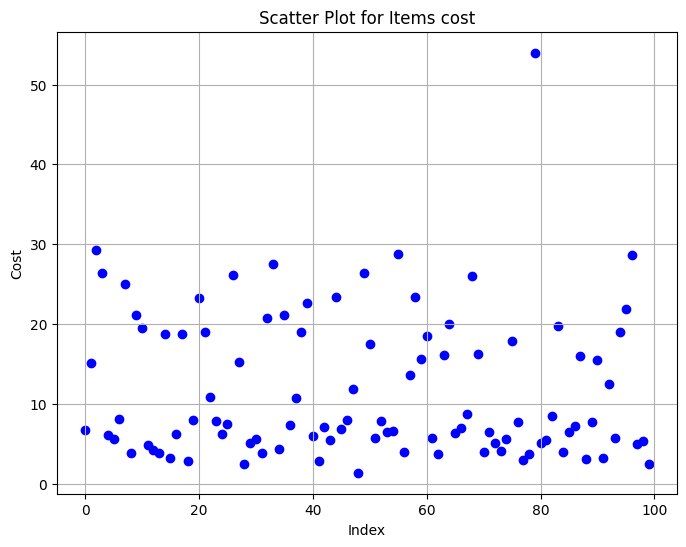

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(df_items.index, df_items['cost'], color='blue', marker='o')

# Add labels and title
plt.xlabel("Index")
plt.ylabel("Cost")
plt.title("Scatter Plot for Items cost")
plt.grid(True)
plt.show()

#Preliminary Analysis of Item Dataset

No NULL values.

Very few outliers. The costliest item price above 50.

Mostly items are priced between 8-30.


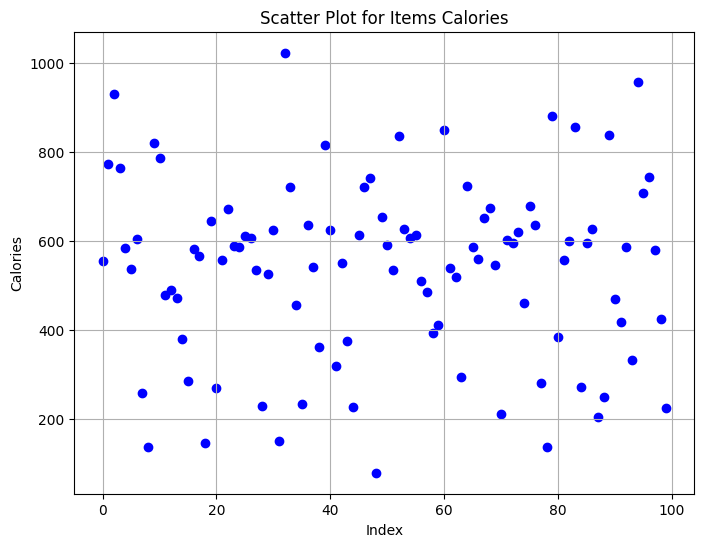

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(df_items.index, df_items['kcal'], color='blue', marker='o')

# Add labels and title
plt.xlabel("Index")
plt.ylabel("Calories")
plt.title("Scatter Plot for Items Calories")

plt.grid(True)

plt.show()

#Preliminary Analysis of Calories feature in Item Dataset

There are few outliers.

Few items have very high calories, above 900kcal.

Mostly items are high in calories ranging between 200-700 kcal.

In [ ]:
df_sales = pd.read_csv("/content/sales.csv")

In [ ]:
df_sales.head()

,date,item_id,price,item_count
0,2019-01-01,3,29.22,2.0
1,2019-01-01,4,26.42,22.0
2,2019-01-01,12,4.87,7.0
3,2019-01-01,13,4.18,12.0
4,2019-01-01,16,3.21,136.0


In [ ]:
df_sales.isnull().sum()

,0
date,0
item_id,0
price,0
item_count,0


In [ ]:
df_sales.describe().T

,count,mean,std,min,25%,50%,75%,max
item_id,109600.0,50.500000,28.866202,1.00,25.75,50.500,75.25,100.00
price,109600.0,11.763700,8.946225,1.39,5.28,7.625,18.79,53.98
item_count,109600.0,6.339297,30.003728,0.00,0.00,0.000,0.00,570.00


In [ ]:
df_sales.shape

(109600, 4)

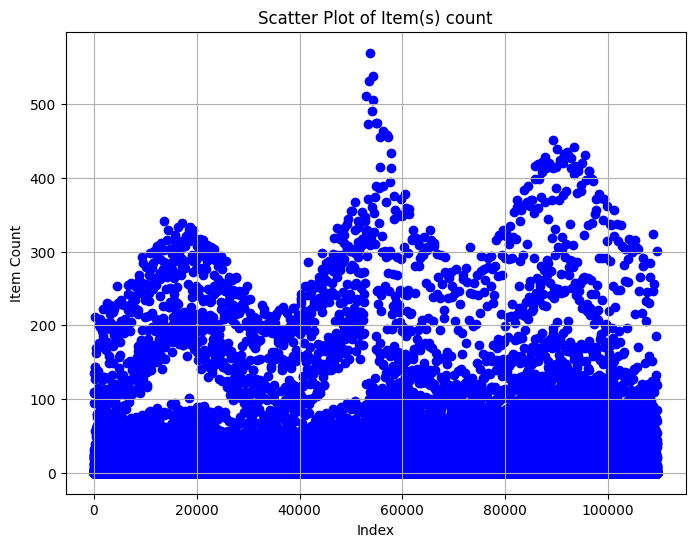

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(df_sales.index, df_sales['item_count'], color='blue', marker='o')

# Add labels and title
plt.xlabel("Index")
plt.ylabel("Item Count")
plt.title("Scatter Plot of Item(s) count")
plt.grid(True)
plt.show()

#Preliminary Analysis for Sales Dataset

No NULL values.

There are few outliers for item count.

Few items are consumed the most and there count is above 500.

Average items consumed count is 6.

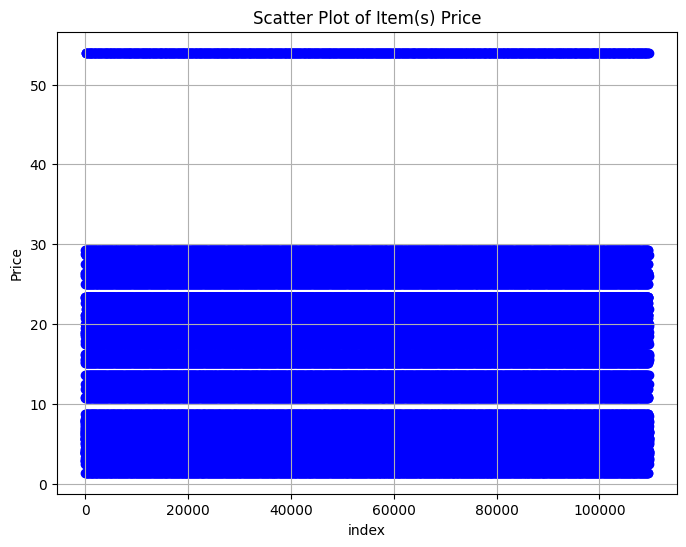

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(df_sales.index, df_sales['price'], color='blue', marker='o')

# Add labels and title
plt.xlabel("index")
plt.ylabel("Price")
plt.title("Scatter Plot of Item(s) Price")
plt.grid(True)
plt.show()

#Preliminary Analysis for Price feature

There are few outliers.

Few item(s) are very costly having price above 50.

Average items price is around 12. Mostly items price is under 20.

In [ ]:
df_res = pd.read_csv("/content/resturants.csv")

In [ ]:
df_res.shape

(6, 2)

In [ ]:
df_res

,id,name
0,1,Bob's Diner
1,2,Beachfront Bar
2,3,Sweet Shack
3,4,Fou Cher
4,5,Corner Cafe
5,6,Surfs Up


In [ ]:
df_items = df_items.rename(columns={"name": "item_name"})
df_res = df_res.rename(columns={"name": "store_name"})
df_res = df_res.rename(columns={"id": "store_id"})

#Merge the datasets into a single dataset that includes the date, item id, price, item count, item, names, kcal values, store id, and store name

In [ ]:
df_merged = pd.merge(df_sales, df_items, left_on="item_id", right_on="id").drop("id", axis =1)

In [ ]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109600 entries, 0 to 109599
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   date        109600 non-null  object 
 1   item_id     109600 non-null  int64  
 2   price       109600 non-null  float64
 3   item_count  109600 non-null  float64
 4   store_id    109600 non-null  int64  
 5   item_name   109600 non-null  object 
 6   kcal        109600 non-null  int64  
 7   cost        109600 non-null  float64
dtypes: float64(3), int64(3), object(2)
memory usage: 6.7+ MB


In [ ]:
df_merged = df_merged.drop('cost', axis=1)
df_merged = pd.merge(df_merged, df_res, on="store_id")


In [ ]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109600 entries, 0 to 109599
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   date        109600 non-null  object 
 1   item_id     109600 non-null  int64  
 2   price       109600 non-null  float64
 3   item_count  109600 non-null  float64
 4   store_id    109600 non-null  int64  
 5   item_name   109600 non-null  object 
 6   kcal        109600 non-null  int64  
 7   store_name  109600 non-null  object 
dtypes: float64(2), int64(3), object(3)
memory usage: 6.7+ MB


In [ ]:
df_merged.head(10)

,date,item_id,price,item_count,store_id,item_name,kcal,store_name
0,2019-01-01,3,29.22,2.0,1,Sweet Fruity Cake,931,Bob's Diner
1,2019-01-01,4,26.42,22.0,1,Amazing Steak Dinner with Rolls,763,Bob's Diner
2,2019-01-01,12,4.87,7.0,1,Fantastic Sweet Cola,478,Bob's Diner
3,2019-01-01,13,4.18,12.0,1,Sweet Frozen Soft Drink,490,Bob's Diner
4,2019-01-01,16,3.21,136.0,1,Frozen Milky Smoothy,284,Bob's Diner
5,2019-01-01,19,2.89,108.0,1,Strawberry Smoothy,145,Bob's Diner
6,2019-01-01,21,23.23,13.0,1,Amazing Fish with Vegetables Meal,269,Bob's Diner
7,2019-01-01,23,10.86,10.0,1,Awesome Sweet Lamb Cake,671,Bob's Diner
8,2019-01-01,27,26.21,1.0,6,Steak Meal,607,Surfs Up
9,2019-01-01,35,4.36,1.0,6,Blue Ribbon Cocktail,456,Surfs Up


In [ ]:
df_merged.isnull().sum()

,0
date,0
item_id,0
price,0
item_count,0
store_id,0
item_name,0
kcal,0
store_name,0


In [ ]:
df_merged.columns

Index(['date', 'item_id', 'price', 'item_count', 'store_id', 'item_name',
       'kcal', 'store_name'],
      dtype='object')

In [ ]:
# Convert date to datetime format
df_merged['date'] = pd.to_datetime(df_merged['date'], errors='coerce')

In [ ]:
#Create revenue column for total revenue generated from sale of item
df_merged['revenue'] = df_merged['price']* df_merged['item_count']

In [ ]:
# Group by date and sum the revenue earned on each date
daily_sales = df_merged.groupby("date")["revenue"].sum().reset_index()

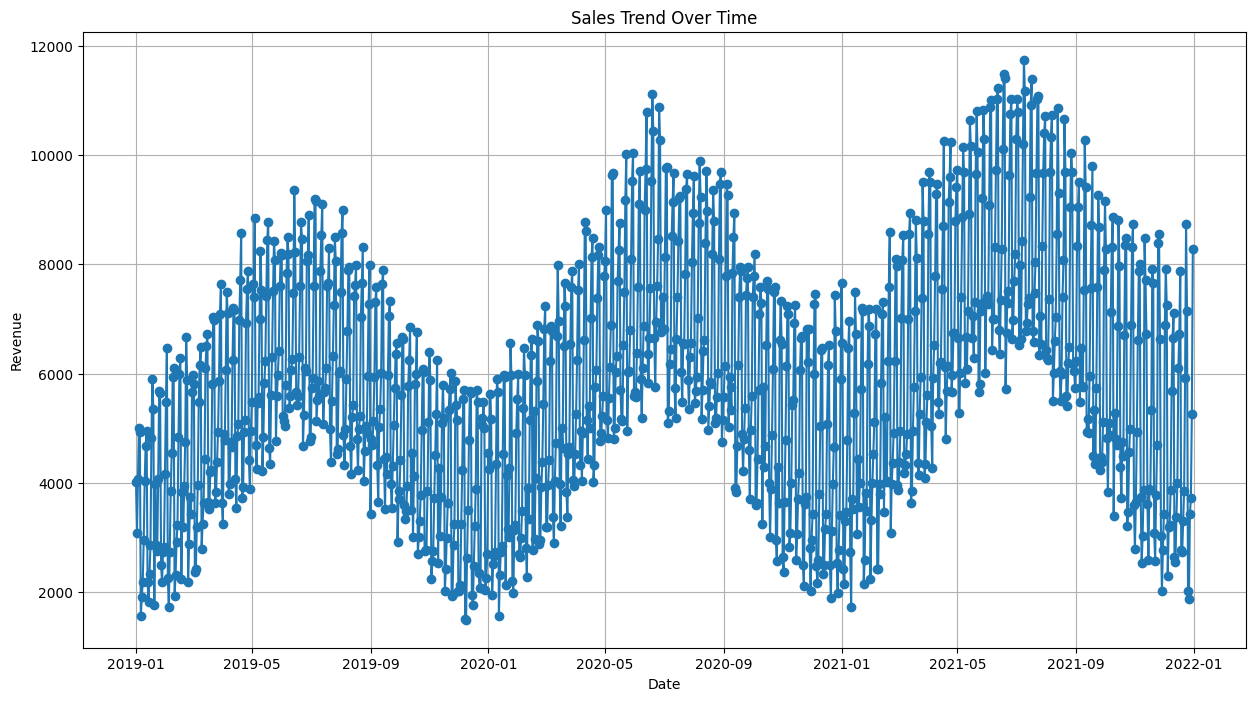

In [ ]:
plt.figure(figsize=(15,8))
plt.plot(daily_sales['date'], daily_sales['revenue'], marker='o')
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.title("Sales Trend Over Time")
plt.grid(True)
plt.show()

##Overall Sales pattern Analysis

Overall Sales has a seasonal trend and has upward growth trend. As every year the revenue peak is increasing.

Peak in sales during Summers.

Fall in sales during winters.

#How Sales fluctuate across different days of the week

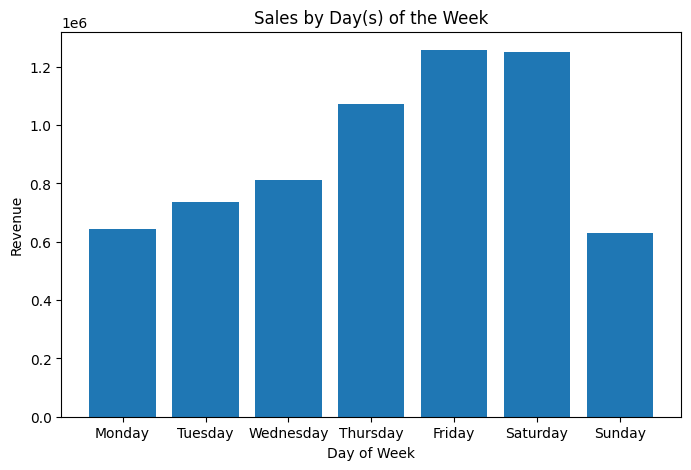

In [ ]:
# Extract weekday name from date
df_merged['weekday'] = df_merged['date'].dt.day_name()

# Set proper weekday order
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
df_merged['weekday'] = pd.Categorical(df_merged['weekday'], categories=weekday_order, ordered=True)

# Calculate average revenue per weekday
weekday_sales = df_merged.groupby('weekday', observed=False)['revenue'].sum()

# Plot Sales fluctuation by weekday
plt.figure(figsize=(8, 5))
plt.bar(weekday_sales.index, weekday_sales.values)
plt.title("Sales by Day(s) of the Week")
plt.xlabel("Day of Week")
plt.ylabel("Revenue")
plt.show()


#Sales Trend over weekdays

Sale increases as the weekend arrives.Its highest on Friday and Saturday.

Sale starts to drop from Sunday and again increases as weekend approaches.

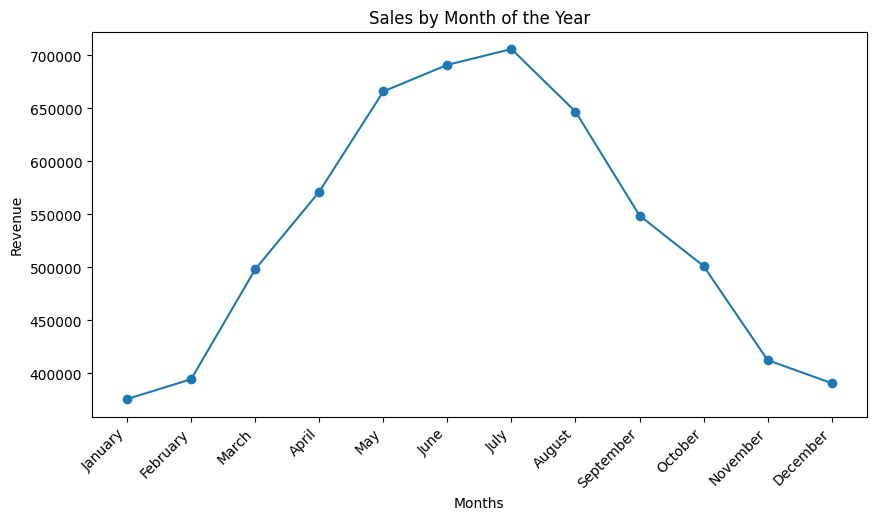

In [ ]:
# Extract Month name from date
df_merged['day'] = df_merged['date'].dt.day
df_merged['month'] = df_merged['date'].dt.month
df_merged['month_name'] = df_merged['date'].dt.month_name().astype(str)

# Set proper month order
month_order = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]
df_merged['month_name'] = pd.Categorical(df_merged['month_name'], categories=month_order, ordered=True)

# Calculate average revenue per month
monthly_sales = df_merged.groupby('month_name', observed=False)['revenue'].sum()

#Plot Sales fluctuation by Month of the year
plt.figure(figsize=(10, 5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o')
plt.title("Sales by Month of the Year")
plt.xlabel("Months")
plt.ylabel("Revenue")
plt.xticks(rotation=45, ha='right')
plt.show()

#Trends in the sales data for different months of the year

Sales is highest during Summers i.e May, June, July.

Sale starts increasing Feb onwards and decreases from July onwards. Major business season is between March and Sept.

There is least business during winters.

In [ ]:
df_merged['month_name'] = df_merged['date'].dt.month_name().astype(str)

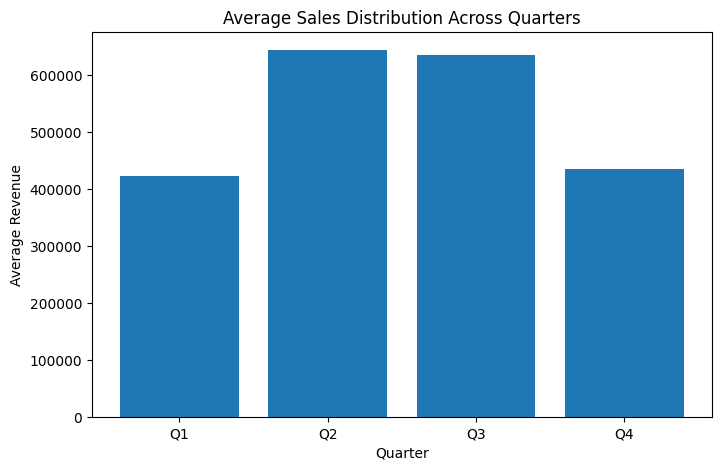

In [ ]:
# Extract quarter and year
df_merged['quarter'] = df_merged['date'].dt.to_period('Q').astype(str)
df_merged['quarter_num'] = df_merged['date'].dt.quarter
df_merged['year'] = df_merged['date'].dt.year

# Compute total revenue per year per quarter
quarterly_sales = df_merged.groupby(['year', 'quarter_num'])['revenue'].sum().reset_index()

# Now compute average revenue per quarter across all years
avg_quarter_sales = quarterly_sales.groupby('quarter_num')['revenue'].mean()

quarter_labels = ['Q1', 'Q2', 'Q3', 'Q4']
# Plot quarterly sales distribution
plt.figure(figsize=(8, 5))
plt.bar(quarter_labels, avg_quarter_sales.values)
plt.title("Average Sales Distribution Across Quarters")
plt.xlabel("Quarter")
plt.ylabel("Average Revenue")
plt.show()

#Sales is highest during Q2 and Q3 quarters.

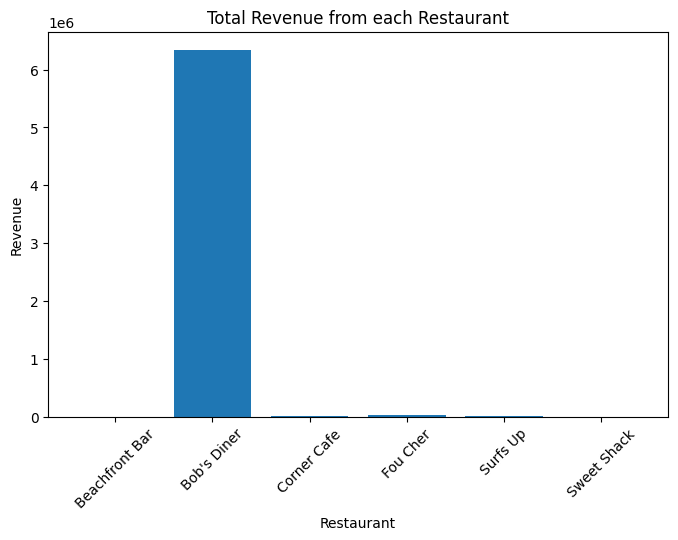

In [ ]:
# Now compute total revenue per Restaurant
store_sales = df_merged.groupby('store_name')['revenue'].sum().round()

# Plot sales distribution by each restaurant
plt.figure(figsize=(8, 5))
plt.bar(store_sales.index, store_sales.values)
plt.title("Total Revenue from each Restaurant")
plt.xlabel("Restaurant")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

# Restaurant - Bob's Dinner, has the maximum sale amongst all the restaurants.

In [ ]:
# Aggregate yearly revenue per store
store_yearly_sales = (
    df_merged.groupby(['store_name', 'year'], observed=False)['revenue']
      .mean()
      .reset_index()
)

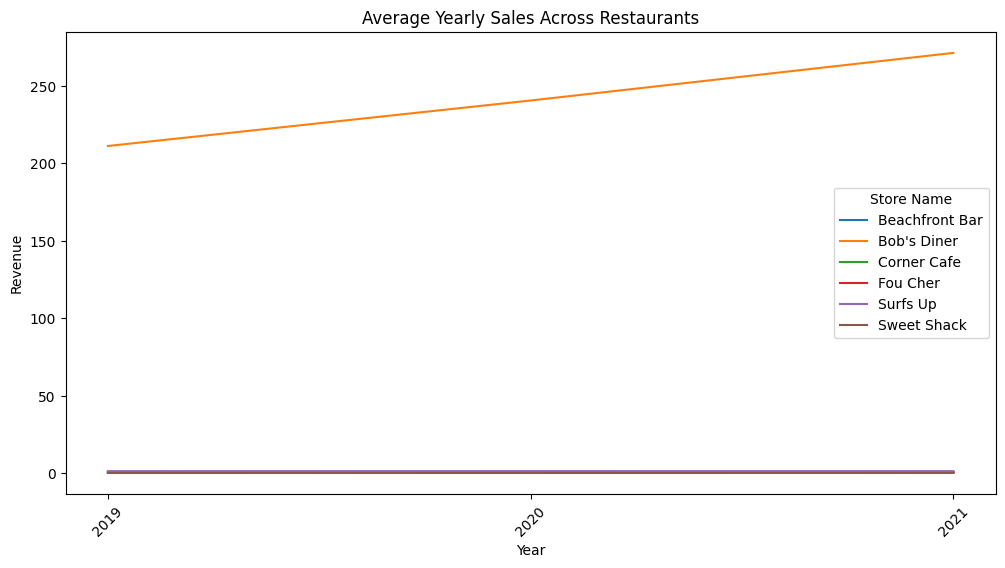

In [ ]:
# Convert year to string for plotting
store_yearly_sales['year'] = store_yearly_sales['year'].astype(str)

plt.figure(figsize=(12, 6))

for store in store_yearly_sales['store_name'].unique():
    store_data = store_yearly_sales[store_yearly_sales['store_name'] == store]
    plt.plot(store_data['year'], store_data['revenue'], label=f"{store}")

plt.title("Average Yearly Sales Across Restaurants")
plt.xticks(rotation=45)
plt.xlabel("Year")
plt.ylabel("Revenue")
plt.legend(title="Store Name")
plt.show()

In [ ]:
store_yearly_sales.pivot(
    index='year',
    columns='store_name',
    values='revenue'
)

store_name,Beachfront Bar,Bob's Diner,Corner Cafe,Fou Cher,Surfs Up,Sweet Shack
year,,,,,,
2019,0.585320,211.128252,0.604216,0.949002,1.406205,0.298832
2020,0.577054,240.474944,0.608801,0.838297,1.452030,0.283009
2021,0.569470,271.171266,0.674748,0.938914,1.425866,0.300353


##Average Yearly Sales Trend
 Shows increasing Sales trend for restaurant - Bob's Dinner.

 Whereas for  all other  restaurants, the average of yearly revenue is very low. Thus staright line is observed. And across the years there is no significant business growth observed.

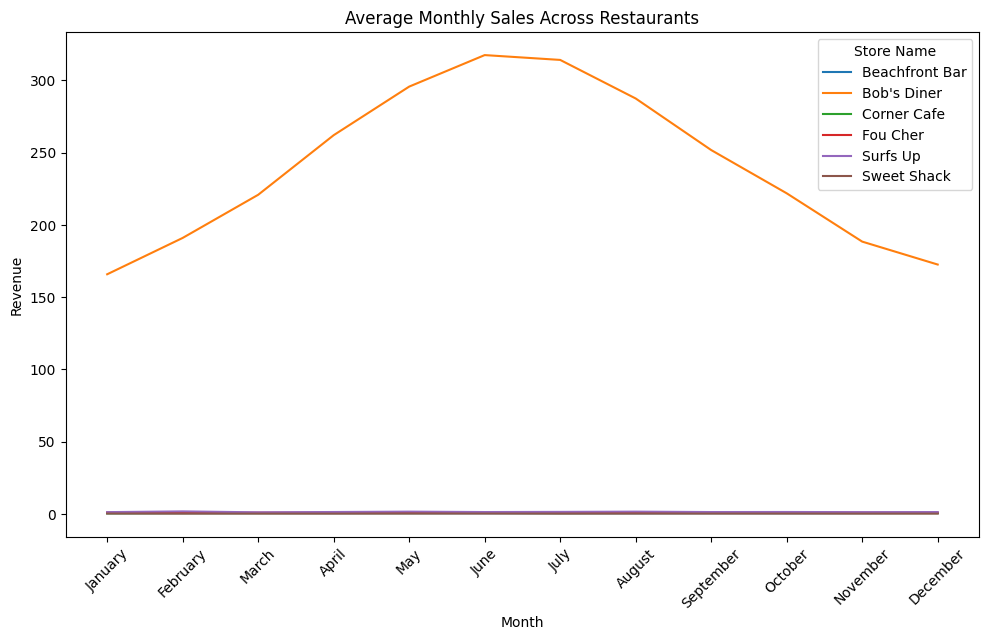

In [ ]:
# Aggregate monthly revenue per store
store_montly_sales = (
    df_merged.groupby(['store_name', 'month_name'], observed=True)['revenue']
      .mean()
      .reset_index()
)

# Set proper month order
month_order = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]
store_montly_sales['month_name'] = pd.Categorical(store_montly_sales['month_name'], categories=month_order, ordered=True)

plt.figure(figsize=(10, 6))

for store in store_montly_sales['store_name'].unique():
    store_data = store_montly_sales.loc[store_montly_sales['store_name'] == store].copy()
    store_data = store_data.sort_values("month_name")
    plt.plot(store_data['month_name'], store_data['revenue'], label=f"{store}")

plt.title("Average Monthly Sales Across Restaurants")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.legend(title="Store Name")
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()

In [ ]:
store_montly_sales.pivot(
    index='month_name',
    columns='store_name',
    values='revenue'
)

store_name,Beachfront Bar,Bob's Diner,Corner Cafe,Fou Cher,Surfs Up,Sweet Shack
month_name,,,,,,
January,0.565502,165.814323,0.473109,1.092051,1.301957,0.341935
February,0.623725,190.956461,0.608559,0.713050,1.809376,0.267074
March,0.609731,220.800103,0.598360,0.928341,1.165570,0.290202
April,0.588111,262.020523,0.645537,0.929683,1.386100,0.266431
May,0.596129,295.617818,0.613916,1.068683,1.638688,0.315148
June,0.542704,317.414731,0.715736,0.877901,1.357944,0.314903
July,0.535968,314.073925,0.590869,0.704293,1.471022,0.276707
August,0.509642,287.397715,0.682814,0.768502,1.638602,0.295390
September,0.566130,251.728458,0.669231,0.796933,1.355933,0.297306


##Average Monthly Sales Trend across Restaurants
  Bob's Dinner has seasonal trend as oberved before. There is peak during summer i.e in May, June, July.

 Whereas for  all other  restaurants, the avearge monthly sales is very low and thus the trend show a straight line. Looks like there is not much business growth over the year.

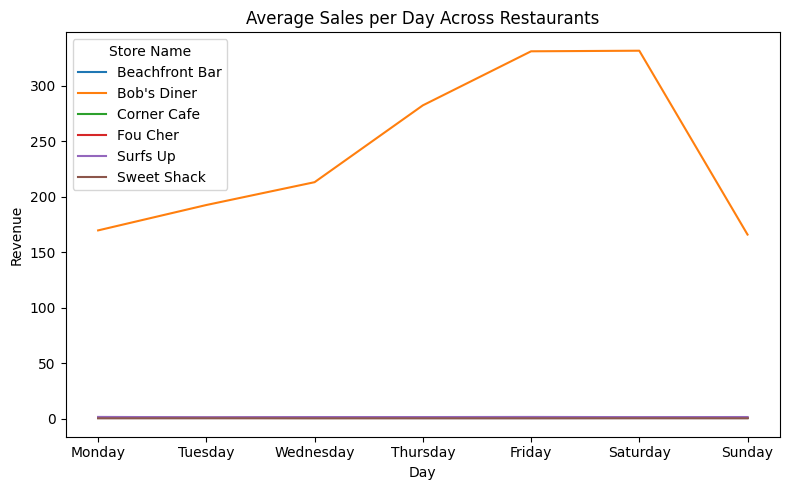

In [ ]:
# Aggregate revenue for WeekDays per store
store_weekDays_sales = (
    df_merged.groupby(['store_name', 'weekday'], observed=False)['revenue']
      .mean()
      .reset_index()
)
plt.figure(figsize=(8, 5))

for store in store_weekDays_sales['store_name'].unique():
    store_data = store_weekDays_sales[store_weekDays_sales['store_name'] == store]
    plt.plot(store_data['weekday'], store_data['revenue'], label=f"{store}")

plt.title("Average Sales per Day Across Restaurants")
plt.xlabel("Day")
plt.ylabel("Revenue")
plt.legend(title="Store Name")
plt.tight_layout()
plt.show()

In [ ]:
#Fetch most popular items overall
most_sold_item = (
  df_merged.groupby('item_name')['item_count'].sum().sort_values(ascending=False)
)

# Select top 10 items
top10_items = most_sold_item.head(10)

In [ ]:
most_sold_item.head(10)

,item_count
item_name,
Strawberry Smoothy,236337.0
Frozen Milky Smoothy,103263.0
Amazing pork lunch,61043.0
Mutton Dinner,52772.0
Orange Juice,43874.0
Blue Ribbon Beef Entree,42774.0
Amazing Steak Dinner with Rolls,34439.0
Sweet Frozen Soft Drink,27490.0
Sea Bass with Vegetables Dinner,23839.0


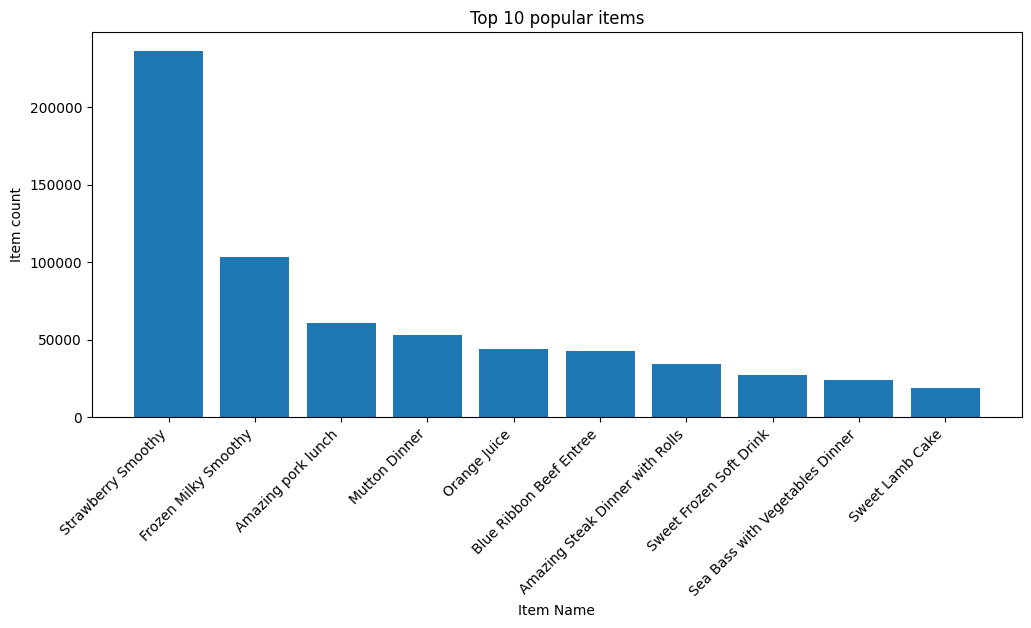

In [ ]:
# Plot 10 most popular items
plt.figure(figsize=(12, 5))
plt.bar(top10_items.index, top10_items.values)
plt.title("Top 10 popular items")
plt.xlabel("Item Name")
plt.ylabel("Item count")
plt.xticks(rotation=45, ha='right')
plt.show()

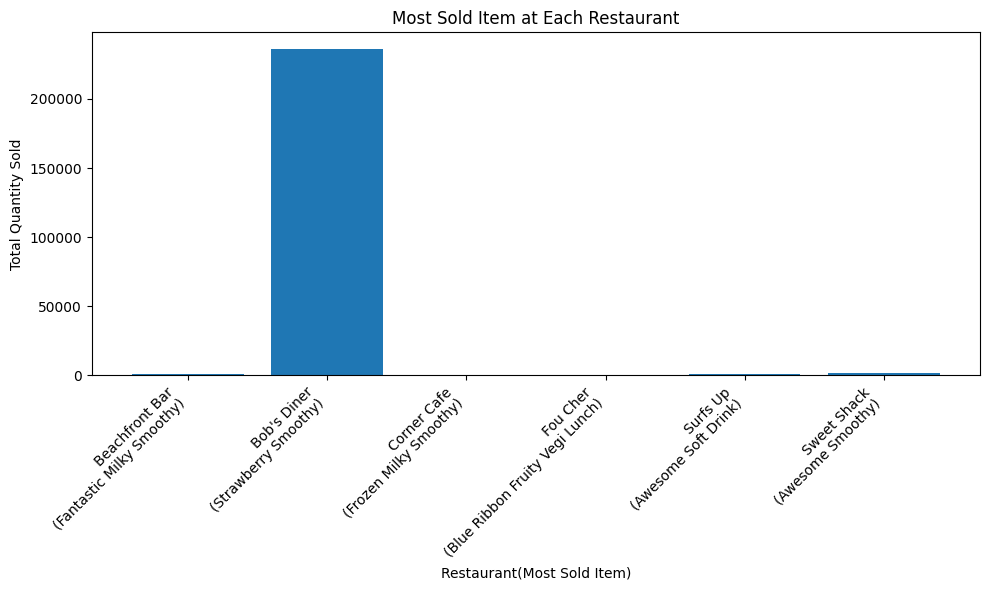

In [ ]:
#most popular items overall and the stores where they are being sold.
most_sold_item = (
  df_merged.groupby(['store_name', 'item_name'])['item_count'].sum().reset_index()
)

idx = most_sold_item.groupby('store_name')['item_count'].idxmax()

top_item_per_store = most_sold_item.loc[idx]

labels = top_item_per_store['store_name'] + "\n(" + top_item_per_store['item_name'] + ")"


plt.figure(figsize=(10, 6))
plt.bar(labels,
        top_item_per_store['item_count'])

plt.title("Most Sold Item at Each Restaurant")
plt.xlabel("Restaurant(Most Sold Item)")
plt.ylabel("Total Quantity Sold")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
top_item_per_store

,store_name,item_name,item_count
1,Beachfront Bar,Fantastic Milky Smoothy,1147.0
25,Bob's Diner,Strawberry Smoothy,236337.0
40,Corner Cafe,Frozen Milky Smoothy,273.0
57,Fou Cher,Blue Ribbon Fruity Vegi Lunch,298.0
85,Surfs Up,Awesome Soft Drink,997.0
92,Sweet Shack,Awesome Smoothy,1692.0


#The most popular item overall
Strawberry Smoothy is most popular item and is sold at Bob's Diner.

In [ ]:
#Fetch most popular items overall
sold_item_count = (
  df_merged.groupby('store_name')['item_count'].sum().sort_values(ascending=False)
)
sold_item_revenue = (
  df_merged.groupby('store_name')['revenue'].sum().sort_values(ascending=False)
)

In [ ]:
sold_item_count

,item_count
store_name,
Bob's Diner,687527.0
Surfs Up,1803.0
Sweet Shack,1736.0
Corner Cafe,1310.0
Beachfront Bar,1305.0
Fou Cher,1106.0


In [ ]:
sold_item_revenue

,revenue
store_name,
Bob's Diner,6337275.69
Fou Cher,27885.37
Corner Cafe,16551.43
Surfs Up,15651.49
Beachfront Bar,3796.20
Sweet Shack,2578.27


#Bob's Diner is making the highest Sale and has the highest revenue too

In [ ]:
#most expensive item at each restaurant and its calories.
store_item_list = (
  df_merged.groupby(['store_name', 'item_name', 'kcal'])['price'].max().reset_index()
)

idx = store_item_list.groupby('store_name')['price'].idxmax()
most_expensive_item_per_store = store_item_list.loc[idx]
most_expensive_item_per_store.sort_values(by='price')

,store_name,item_name,kcal,price
5,Beachfront Bar,Sweet Vegi Soft Drink,538,5.70
93,Sweet Shack,Blue Ribbon Frozen Milky Cake,636,7.70
91,Surfs Up,Steak Meal,607,26.21
52,Corner Cafe,Pike Lunch,653,26.37
28,Bob's Diner,Sweet Fruity Cake,931,29.22
57,Fou Cher,Blue Ribbon Fruity Vegi Lunch,881,53.98


#List of most Expensive items at each restaurant and its KCal(s) as above

In [ ]:
#The forecast will be on the total sales everyday i.e we can calculate total revenue per day
daily_revenue =  df_merged.groupby('date')['revenue'].sum().reset_index()

In [ ]:
daily_revenue['day'] = daily_revenue['date'].dt.day
daily_revenue['weekday'] = daily_revenue['date'].dt.weekday
daily_revenue['month'] = daily_revenue['date'].dt.month
daily_revenue['quarter'] = daily_revenue['date'].dt.quarter
daily_revenue['year'] = daily_revenue['date'].dt.year

In [ ]:
#Test data is from last 6 months i.e from 2021-07-01 until 2021-12-31
cutoff_date = daily_revenue['date'].max() - pd.DateOffset(months=6)

train = daily_revenue[daily_revenue['date'] <= cutoff_date]
test  = daily_revenue[daily_revenue['date'] > cutoff_date]

X_train = train[['day','weekday','month', 'quarter', 'year']]
y_train = train['revenue']

X_test  = test[['day','weekday','month', 'quarter', 'year']]
y_test  = test['revenue']

#Train with LinearRegression model

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_train)
lr_rmse_train = mean_squared_error(y_train, lr_pred)

lr_pred = lr.predict(X_test)
lr_rmse_test = mean_squared_error(y_test, lr_pred)

print("Root Mean Squared Error for train data : ", round(lr_rmse_train,3))
print("Root Mean Squared Error for test data : ", round(lr_rmse_test,3))

Root Mean Squared Error for train data :  3816231.842
Root Mean Squared Error for test data :  5720210.707


#Train with RandomForest model

In [ ]:
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_train)
rf_rmse_train = mean_squared_error(y_train, rf_pred)

rf_pred = rf.predict(X_test)
rf_rmse_test = mean_squared_error(y_test, rf_pred)

print("Root Mean Squared Error for train data : ", round(rf_rmse_train,3))
print("Root Mean Squared Error for test data : ", round(rf_rmse_test,3))

Root Mean Squared Error for train data :  33284.959
Root Mean Squared Error for test data :  728598.341


#Train with XGBoost model

In [ ]:
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_train)
xgb_rmse_train = mean_squared_error(y_train, xgb_pred)

xgb_pred = xgb.predict(X_test)
xgb_rmse_test = mean_squared_error(y_test, xgb_pred)

print("Root Mean Squared Error for train data : ", round(xgb_rmse_train,3))
print("Root Mean Squared Error for test data : ", round(xgb_rmse_test,3))

Root Mean Squared Error for train data :  26640.595
Root Mean Squared Error for test data :  464339.307


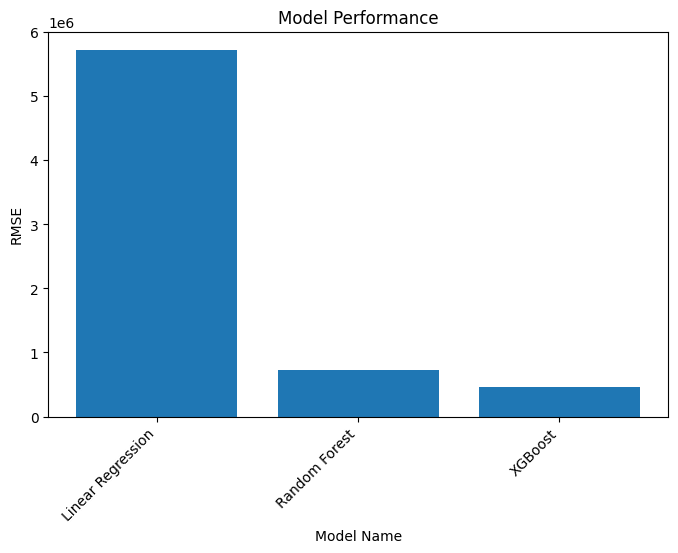

In [ ]:
rmse_dataframe = pd.DataFrame(
    {
    "Model": ["Linear Regression", "Random Forest", "XGBoost"],
    "RMSE": [lr_rmse_test, rf_rmse_test, xgb_rmse_test]
    }
)

plt.figure(figsize=(8, 5))
plt.bar(rmse_dataframe.Model, rmse_dataframe.RMSE)
plt.title("Model Performance")
plt.xlabel("Model Name")
plt.ylabel("RMSE")
plt.xticks(rotation=45, ha='right')
plt.show()


XGBoost has the least RMSE value compared to all the models. Thus XGBoost is the best performing model.

##Using XGBoost model to forecast for the next year

In [ ]:
#Generate dataset for the next year and then Train the model on the complete dataset provided

X_train = daily_revenue[['day','weekday','month', 'quarter', 'year']]
y_train = daily_revenue['revenue']

xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
#Create forecast dataframe using the future dates for next year i.e from 01-01-2022 to 31-12-2022
future_dates = pd.date_range(
    start=daily_revenue['date'].max() + pd.Timedelta(days=1),
    periods=365
)

forecast_df = pd.DataFrame({'date': future_dates})

forecast_df['day'] = forecast_df['date'].dt.day
forecast_df['weekday'] = forecast_df['date'].dt.dayofweek
forecast_df['month'] = forecast_df['date'].dt.month
forecast_df['quarter'] = forecast_df['date'].dt.quarter
forecast_df['year'] = forecast_df['date'].dt.year

#Forecast revenue for the future dates
X_test = forecast_df[['day','weekday','month','quarter', 'year']]

forecast_df['revenue'] = xgb.predict(X_test)

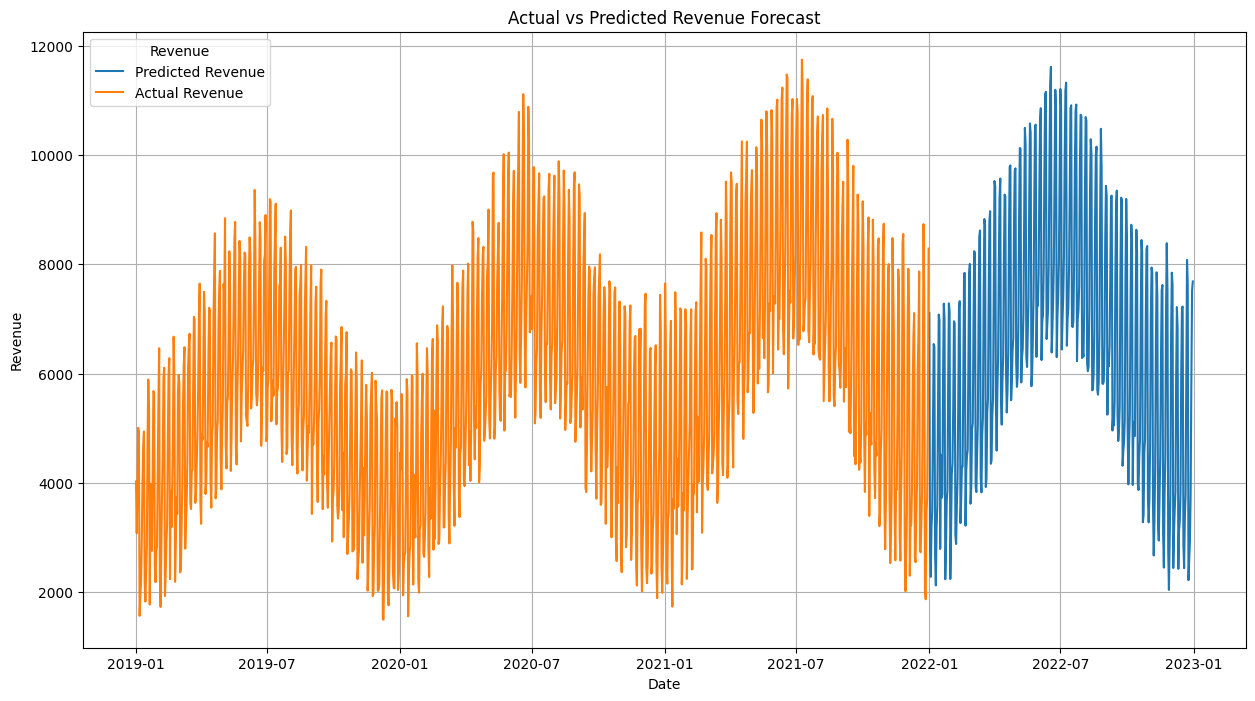

In [ ]:
plt.figure(figsize=(15,8))
plt.plot(forecast_df['date'], forecast_df['revenue'], label='Predicted Revenue')
plt.plot(daily_revenue['date'], daily_revenue['revenue'], label='Actual Revenue')

plt.xlabel("Date")
plt.ylabel("Revenue")
plt.title("Actual vs Predicted Revenue Forecast")
plt.legend(title="Revenue")
plt.grid(True)
plt.show()

##Analysis on Forecasted Revenue data for the next year

The seasonality of sales trend appear similar.

The peak is observed during July for the previous years and for predicted also its same.

Does not appear anything is broken or out of range.
